<a href="https://colab.research.google.com/github/AHegab/AHegab/blob/main/aml3_martin_skrtel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
train=pd.read_csv("/content/train.csv")
val=pd.read_csv("/content/val.csv")
def convert_volume(value):
    if isinstance(value, str):
        value = value.strip().upper()
        if value.endswith('M'):
            return float(value[:-1]) * 1_000_000
        elif value.endswith('K'):
            return float(value[:-1]) * 1_000
    return float(value)

train['Vol.'] = train['Vol.'].apply(convert_volume)
val['Vol.'] = val['Vol.'].apply(convert_volume)



import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Assuming 'train' and 'val' are your DataFrames with a Date column and stock data columns

# Convert the 'Date' column to datetime for both train and val
train['Date'] = pd.to_datetime(train['Date'])
val['Date'] = pd.to_datetime(val['Date'])

# Extract useful time features for train and val
for dataset in [train, val]:
    dataset['Year'] = dataset['Date'].dt.year
    dataset['Month'] = dataset['Date'].dt.month
    dataset['Day'] = dataset['Date'].dt.day
    dataset['Weekday'] = dataset['Date'].dt.weekday  # 0 = Monday
    dataset['DayOfYear'] = dataset['Date'].dt.dayofyear
    dataset['Time_Index'] = (dataset['Date'] - dataset['Date'].min()).dt.days  # linear time index

# Drop original Date column for both train and val
train = train.drop(columns=['Date'])
val = val.drop(columns=['Date'])



#################
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize MinMaxScaler for both features and target
# Feature columns that you want to normalize
numerical_columns = ['Open',  'High', 'Low', 'Vol.', 'Year', 'Month', 'Day', 'Weekday', 'DayOfYear', 'Time_Index']

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Normalize the input features
train[numerical_columns] = feature_scaler.fit_transform(train[numerical_columns])
val[numerical_columns] = feature_scaler.transform(val[numerical_columns])

# Normalize the 'Price' (target) column for both train and validation data
train['Price'] = target_scaler.fit_transform(train[['Price']])
val['Price'] = target_scaler.transform(val[['Price']])


###############################
# Verify the transformed DataFrames
print("Transformed Train Data:")
print(train.head())

print("\nTransformed Validation Data:")
print(val.head())

# Define a function to create sequences for LSTM
def create_sequences(data, sequence_length=30):
    sequences = []
    targets = []
    for i in range(sequence_length, len(data)):
        sequences.append(data.iloc[i-sequence_length:i].values)  # Get sequence of 60 days
        targets.append(data.iloc[i]['Price'])  # Target is 'Close' price
    return np.array(sequences), np.array(targets)

# Create sequences from the training and validation data
X_train, y_train = create_sequences(train)
X_val, y_val = create_sequences(val)

# Verify the shape
print(X_train.shape, X_val.shape)
# Load the test data
test = pd.read_csv("/content/test_without_label.csv")

# Apply the volume conversion function to the 'Vol.' column
test['Vol.'] = test['Vol.'].apply(convert_volume)

# Convert 'Date' column to datetime
test['Date'] = pd.to_datetime(test['Date'])

# Extract useful time features
test['Year'] = test['Date'].dt.year
test['Month'] = test['Date'].dt.month
test['Day'] = test['Date'].dt.day
test['Weekday'] = test['Date'].dt.weekday
test['DayOfYear'] = test['Date'].dt.dayofyear
test['Time_Index'] = (test['Date'] - test['Date'].min()).dt.days

# Drop original 'Date' column
test = test.drop(columns=['Date'])

# Normalize features using the scaler fitted on the training data
test[numerical_columns] = feature_scaler.transform(test[numerical_columns])

# Create sequences from the test data
def create_sequences_without_targets(data, sequence_length=30):
    sequences = []
    for i in range(sequence_length, len(data)):
        sequences.append(data.iloc[i-sequence_length:i].values)  # Get sequence of 60 days
    return np.array(sequences)

X_test = create_sequences_without_targets(test)

Transformed Train Data:
      Price      Open      High       Low      Vol.      Year  Month  \
0  0.000543  0.000814  0.000534  0.000828  0.011006  0.000000    1.0   
1  0.000543  0.000814  0.000267  0.000552  0.006131  0.066667    0.0   
2  0.000543  0.000271  0.000267  0.000552  0.007937  0.066667    0.0   
3  0.000814  0.000542  0.000801  0.000828  0.029261  0.066667    0.0   
4  0.000814  0.001899  0.001335  0.001104  0.023338  0.066667    0.0   

        Day   Weekday  DayOfYear  Time_Index  
0  1.000000  0.333333   0.997253    0.000000  
1  0.100000  1.000000   0.005495    0.000730  
2  0.133333  0.000000   0.008242    0.000913  
3  0.166667  0.166667   0.010989    0.001095  
4  0.233333  0.500000   0.016484    0.001460  

Transformed Validation Data:
      Price      Open      High       Low      Vol.      Year  Month  \
0  0.774010  0.771630  0.770895  0.781612  0.003188  1.000000    1.0   
1  0.793543  0.778139  0.789052  0.792656  0.002917  1.066667    0.0   
2  0.797884  0.

In [ ]:
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# === Define Input Shape ===
sequence_length = X_train.shape[1]
num_features = X_train.shape[2]
inputs = Input(shape=(sequence_length, num_features))


# === CNN Block (Simplified) ===
x = Conv1D(filters=64, kernel_size=5, activation='relu', kernel_regularizer=l2(0.001))(inputs)
x = MaxPooling1D(pool_size=4)(x)

x = LSTM(64, return_sequences=True)(inputs)  # Add LSTM layer here
x = LSTM(32, return_sequences=True)(x)  # Another LSTM layer for further processing, **modified to return sequences**

# === Dense Layer (Simplified) ===
x = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dense(16, activation='relu', kernel_regularizer=l2(0.001))(x)

# === Output Layer ===
output = Dense(1, kernel_regularizer=l2(0.001))(x)
# === Compile Model ===
model = Model(inputs=inputs, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.005), loss='mse')

# === Summary ===
model.summary()

# === Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)



Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 30, 11)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 30, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 30, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 30, 32)         │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 30, 16)         │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 30, 1)          │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,473 (130.75 KB)

 Trainable params: 33,473 (130.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# === Fit Model (Assuming you have data) ===
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32, callbacks=[early_stop])


Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.1097 - val_loss: 0.4317
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0750 - val_loss: 0.3901
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0729 - val_loss: 0.4021
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0701 - val_loss: 0.3831
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0718 - val_loss: 0.3935
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 0.0703 - val_loss: 0.4146
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 0.0738 - val_loss: 0.3885
Epoch 8/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0712 - val_loss: 0.3765
Epoch 9/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0737 - val_loss: 0.3992
Epoch 10/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0683 - val_loss: 0.3793
Epoch 11/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0710 - val_loss: 0.3926
Epoch 12/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import pandas as pd
import numpy as np

# Predict on test data (scaled output)
pred_scaled = model.predict(X_test) # Use the original X_test

# Inverse scale to get actual predicted prices
predicted_prices = target_scaler.inverse_transform(pred_scaled)

# Create DataFrame from predictions
predicted_df = pd.DataFrame(predicted_prices, columns=['Predicted_Price'])

# Preview
print(predicted_df.head())

# Save predictions to CSV
predicted_df.to_csv("predicted_stock_prices.csv", index=False)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
   Predicted_Price
0       543.476379
1       543.515808
2       543.551880
3       543.585205
4       543.618591


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# Convert Vol column from strings with K/M to numeric
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    else:
        return vol_str

train["Vol."] = train["Vol."].apply(convert_volume)
val["Vol."] = val["Vol."].apply(convert_volume)
test["Vol."] = test["Vol."].apply(convert_volume)

# Feature engineering function without lag or target-dependent features
def engineer_features_no_lag(df):
    df = df.copy()

    # Basic derived features
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])

    # Date features
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df["day_of_week"] = df["Date"].dt.dayofweek
        df["month"] = df["Date"].dt.month
        df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    else:
        # If no Date column, create default values (optional)
        df["day_of_week"] = 0
        df["month"] = 0
        df["is_weekend"] = 0

    return df

# Apply feature engineering
train_fe = engineer_features_no_lag(train)
val_fe = engineer_features_no_lag(val)
test_fe = engineer_features_no_lag(test)

# Define features to use (exclude target and Date)
features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]

X_val = val_fe[features]
y_val = val_fe["Price"]

X_test = test_fe[features]

# Train XGBoost model
model = XGBRegressor(
    colsample_bytree=0.8,
    learning_rate=0.05,
    max_depth=3,
    n_estimators=200,
    subsample=1,
    random_state=42
)
model.fit(X_train, y_train)

# Validate
val_preds = model.predict(X_val)
mae = mean_absolute_error(y_val, val_preds)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print(f"Validation MAE: {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")

# Predict on test
test_preds = model.predict(X_test)

# Save test predictions with ID
submission = pd.DataFrame({
    "ID": test["ID"],
    "Predicted_Close": test_preds
})
submission.to_csv("predictionsyt.csv", index=False)
print("Test predictions saved to predictions.csv ✅")


Validation MAE: 0.7050
Validation RMSE: 1.3765
Test predictions saved to predictions.csv ✅


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid

# Your existing code for loading, converting volumes and feature engineering here ...
# (Make sure train_fe, val_fe, features, y_train, y_val are defined as in your code)

# Define grid of parameters to search
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.02, 0.05],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1],
    "reg_alpha": [0, 0.1, 0.5],       # L1 regularization
    "reg_lambda": [1, 1.5, 2],        # L2 regularization
    "gamma": [0, 0.1, 0.5],           # Tree complexity regularization
    "random_state": [42]
}

X_train = train_fe[features]
y_train = train_fe["Price"]
X_val = val_fe[features]
y_val = val_fe["Price"]

results = []

print("Starting grid search...")

for params in ParameterGrid(param_grid):
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)

    val_preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, val_preds)
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))

    results.append({
        "params": params,
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"Params: {params} => MAE: {mae:.4f}, RMSE: {rmse:.4f}")

# Convert results to DataFrame for easier sorting
results_df = pd.DataFrame(results)

# Sort by RMSE ascending (best first)
results_df = results_df.sort_values(by="RMSE").reset_index(drop=True)

print("\nTop 5 parameter sets by RMSE:")
print(results_df.head())

# Optionally save results
results_df.to_csv("xgb_grid_search_results.csv", index=False)
print("\nGrid search results saved to xgb_grid_search_results.csv ✅")


Starting grid search...
Params: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'random_state': 42, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.8} => MAE: 9.4344, RMSE: 9.9711
Params: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'random_state': 42, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 1} => MAE: 9.4162, RMSE: 9.9595
Params: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'random_state': 42, 'reg_alpha': 0, 'reg_lambda': 1.5, 'subsample': 0.8} => MAE: 9.4620, RMSE: 10.0030
Params: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'random_state': 42, 'reg_alpha': 0, 'reg_lambda': 1.5, 'subsample': 1} => MAE: 9.4417, RMSE: 9.9875
Params: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'random_state': 42, 'reg_alpha': 0, 'reg_lamb

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# Convert Vol column from strings with K/M to numeric
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    else:
        return vol_str

train["Vol."] = train["Vol."].apply(convert_volume)
val["Vol."] = val["Vol."].apply(convert_volume)
test["Vol."] = test["Vol."].apply(convert_volume)

# Feature engineering function without lag or target-dependent features
def engineer_features_no_lag(df):
    df = df.copy()

    # Basic derived features
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])

    # Date features
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df["day_of_week"] = df["Date"].dt.dayofweek
        df["month"] = df["Date"].dt.month
        df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    else:
        # If no Date column, create default values (optional)
        df["day_of_week"] = 0
        df["month"] = 0
        df["is_weekend"] = 0

    return df

# Apply feature engineering
train_fe = engineer_features_no_lag(train)
val_fe = engineer_features_no_lag(val)
test_fe = engineer_features_no_lag(test)

# Define features to use (exclude target and Date)
features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]

X_val = val_fe[features]
y_val = val_fe["Price"]

X_test = test_fe[features]

# Train XGBoost model


model = XGBRegressor(
    colsample_bytree=0.8,
    gamma=0,
    learning_rate=0.05,
    max_depth=3,
    n_estimators=200,
    random_state=42,
    reg_alpha=0,
    reg_lambda=1,
    subsample=1
)
model.fit(X_train, y_train)

# Validate
val_preds = model.predict(X_val)
mae = mean_absolute_error(y_val, val_preds)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print(f"Validation MAE: {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")

# Predict on test
test_preds = model.predict(X_test)

# Save test predictions with ID
submission = pd.DataFrame({
    "ID": test["ID"],
    "Predicted_Close": test_preds
})
submission.to_csv("predictionsytt6.csv", index=False)
print("Test predictions saved to predictions.csv ✅")


Validation MAE: 0.7050
Validation RMSE: 1.3765
Test predictions saved to predictions.csv ✅


Validation MAE: 0.7334
Validation RMSE: 1.5013


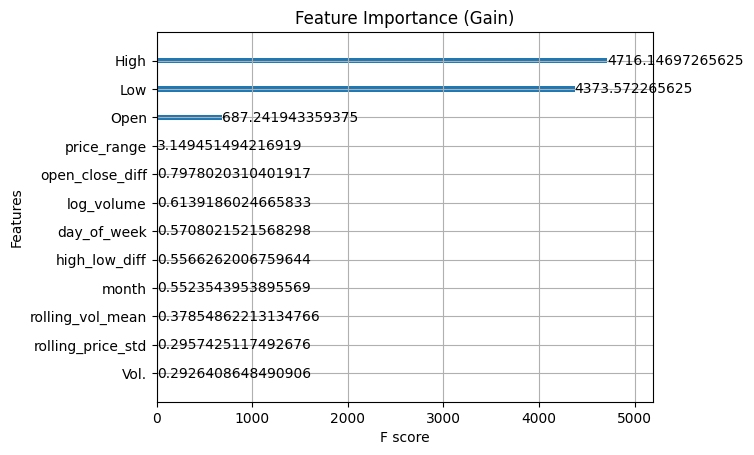

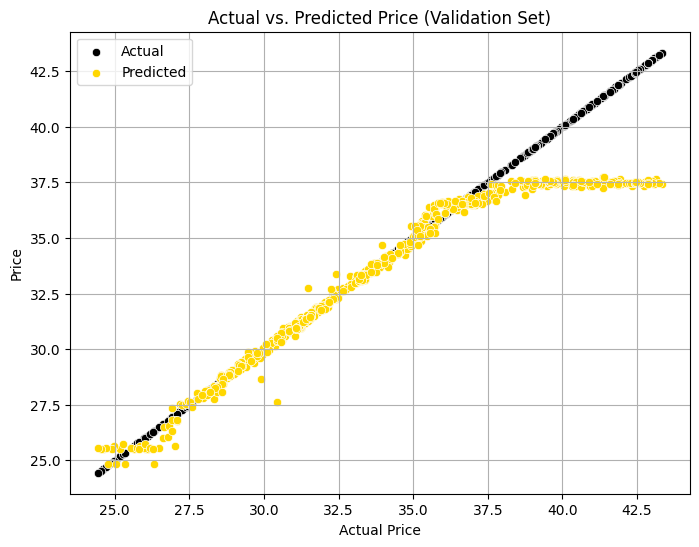

Mapped actuals and predictions saved to val_predictions_mapped.csv ✅
Test predictions saved to predictionsyt.csv ✅


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# Convert Vol column
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    return vol_str

for df in [train, val, test]:
    df["Vol."] = df["Vol."].apply(convert_volume)

# Feature engineering
def engineer_features(df):
    df = df.copy()

    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])

    if "Price" in df.columns:  # Only train/val have target
        df["open_close_diff"] = df["Open"] - df["Price"]
        df["price_range"] = (df["High"] - df["Low"]) / df["Low"]

        df = df.sort_values("Date")
        df["rolling_vol_mean"] = df["Vol."].rolling(window=3, min_periods=1).mean()
        df["rolling_price_std"] = df["Price"].rolling(window=3, min_periods=1).std()
    else:
        df["open_close_diff"] = 0
        df["price_range"] = 0
        df["rolling_vol_mean"] = df["Vol."]
        df["rolling_price_std"] = 0

    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df["day_of_week"] = df["Date"].dt.dayofweek
        df["month"] = df["Date"].dt.month
        df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    else:
        df["day_of_week"] = 0
        df["month"] = 0
        df["is_weekend"] = 0

    return df

# Apply features
train_fe = engineer_features(train)
val_fe = engineer_features(val)
test_fe = engineer_features(test)

# Features used in model
features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "open_close_diff", "price_range",
    "rolling_vol_mean", "rolling_price_std",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]

X_val = val_fe[features]
y_val = val_fe["Price"]

X_test = test_fe[features]

# Train model
model = XGBRegressor(
    colsample_bytree=0.8,
    learning_rate=0.05,
    max_depth=3,
    n_estimators=200,
    subsample=1,
    random_state=42
)
model.fit(X_train, y_train)

# Validation predictions
val_preds = model.predict(X_val)

# Evaluation
mae = mean_absolute_error(y_val, val_preds)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print(f"Validation MAE: {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")

# 📊 Feature Importance Plot
plot_importance(model, importance_type='gain')
plt.title("Feature Importance (Gain)")
plt.show()

# 📈 Actual vs Predicted plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_val, y=y_val, color='black', label='Actual')
sns.scatterplot(x=y_val, y=val_preds, color='gold', label='Predicted')  # yellow color
plt.xlabel("Actual Price")
plt.ylabel("Price")
plt.title("Actual vs. Predicted Price (Validation Set)")
plt.legend()
plt.grid(True)
plt.show()

# 📋 Mapping actuals to predictions
val_results = pd.DataFrame({
    "Actual": y_val,
    "Predicted": val_preds
})
val_results.to_csv("val_predictions_mapped.csv", index=False)
print("Mapped actuals and predictions saved to val_predictions_mapped.csv ✅")

# Predict on test
test_preds = model.predict(X_test)

# Save test predictions
submission = pd.DataFrame({
    "ID": test["ID"],
    "Predicted_Close": test_preds
})
submission.to_csv("predictionsyt2.csv", index=False)
print("Test predictions saved to predictionsyt.csv ✅")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# Convert Vol column from strings with K/M to numeric
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    else:
        return vol_str

train["Vol."] = train["Vol."].apply(convert_volume)
val["Vol."] = val["Vol."].apply(convert_volume)
test["Vol."] = test["Vol."].apply(convert_volume)

# Feature engineering
def engineer_features_no_lag(df):
    df = df.copy()
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df["day_of_week"] = df["Date"].dt.dayofweek
        df["month"] = df["Date"].dt.month
        df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    else:
        df["day_of_week"] = 0
        df["month"] = 0
        df["is_weekend"] = 0
    return df

# Apply feature engineering
train_fe = engineer_features_no_lag(train)
val_fe = engineer_features_no_lag(val)
test_fe = engineer_features_no_lag(test)

# Feature selection
features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]

X_val = val_fe[features]
y_val = val_fe["Price"]

X_test = test_fe[features]

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Validate
val_preds = model.predict(X_val)
mae = mean_absolute_error(y_val, val_preds)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print(f"Validation MAE: {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")

# Predict on test
test_preds = model.predict(X_test)

# Save test predictions with ID
submission = pd.DataFrame({
    "ID": test["ID"],
    "Predicted_Close": test_preds
})
submission.to_csv("predictionslinear.csv", index=False)
print("Test predictions saved to predictions.csv ✅")


Validation MAE: 0.1019
Validation RMSE: 0.1512
Test predictions saved to predictions.csv ✅


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# --- Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# --- Volume conversion
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    return vol_str

for df in [train, val, test]:
    df["Vol."] = df["Vol."].apply(convert_volume)

# --- Feature engineering
def engineer_features(df):
    df = df.copy()
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])
    df["Date"] = pd.to_datetime(df["Date"])
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df

train_fe = engineer_features(train)
val_fe = engineer_features(val)
test_fe = engineer_features(test)

features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]
X_val = val_fe[features]
y_val = val_fe["Price"]
X_test = test_fe[features]

# --- Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Build a linear regression-like neural network
model = Sequential([
    Dense(1, input_shape=(X_train_scaled.shape[1],))  # single neuron, linear output
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# --- Early stopping
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

# --- Train model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# --- Evaluate model
val_preds = model.predict(X_val_scaled).flatten()
mae = mean_absolute_error(y_val, val_preds)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print(f"\nNNK - MAE: {mae:.4f}, RMSE: {rmse:.4f}")

# --- Predict on test set
test_preds = model.predict(X_test_scaled).flatten()

# --- Save predictions
submission = pd.DataFrame({
    "ID": test["ID"],
    "Predicted_Close": test_preds
})
submission.to_csv("NNK1.csv", index=False)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

 NNK - MAE: 6.4683, RMSE: 6.6632
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
✅ Test predictions saved to predictions_deep_learning_model.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import ParameterGrid
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# --- Volume conversion
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    return vol_str

train["Vol."] = train["Vol."].apply(convert_volume)
val["Vol."] = val["Vol."].apply(convert_volume)
test["Vol."] = test["Vol."].apply(convert_volume)

# --- Feature engineering
def engineer_features(df):
    df = df.copy()
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])
    df["Date"] = pd.to_datetime(df["Date"])
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df

train_fe = engineer_features(train)
val_fe = engineer_features(val)
test_fe = engineer_features(test)

features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]
X_val = val_fe[features]
y_val = val_fe["Price"]
X_test = test_fe[features]

# --- Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# --- Volume conversion
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    return vol_str

train["Vol."] = train["Vol."].apply(convert_volume)
val["Vol."] = val["Vol."].apply(convert_volume)
test["Vol."] = test["Vol."].apply(convert_volume)

# --- Feature engineering
def engineer_features(df):
    df = df.copy()
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])
    df["Date"] = pd.to_datetime(df["Date"])
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df

train_fe = engineer_features(train)
val_fe = engineer_features(val)
test_fe = engineer_features(test)

features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]
X_val = val_fe[features]
y_val = val_fe["Price"]
X_test = test_fe[features]

# --- Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Your data loading, preprocessing, and feature engineering here ---
# (keep exactly as you already have it, so X_train_scaled, y_train, etc. are ready)

# Define parameter grid to search
param_grid = {
    "neurons_1": [64, 128],
    "neurons_2": [32, 64],
    "dropout": [0.3, 0.2],
    "batch_size": [16, 32],
    "epochs": [50]  # fixed to 50 for quicker runs with early stopping
}

results = []

print("Starting deep learning grid search...")

for params in ParameterGrid(param_grid):
    # Build model with current params
    model = Sequential([
        Dense(params["neurons_1"], activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(params["dropout"]),
        Dense(params["neurons_2"], activation='relu'),
        Dropout(params["dropout"]),
        Dense(1)  # output layer
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    early_stop = EarlyStopping(patience=5, restore_best_weights=True, verbose=0)

    # Train model
    model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        callbacks=[early_stop],
        verbose=0
    )

    # Predict and evaluate
    val_preds = model.predict(X_val_scaled).flatten()
    mae = mean_absolute_error(y_val, val_preds)
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))

    # Store results
    results.append({
        "neurons_1": params["neurons_1"],
        "neurons_2": params["neurons_2"],
        "dropout": params["dropout"],
        "batch_size": params["batch_size"],
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"Params: {params} => MAE: {mae:.4f}, RMSE: {rmse:.4f}")

# Convert to DataFrame and sort by RMSE
results_df = pd.DataFrame(results).sort_values(by="RMSE").reset_index(drop=True)

print("\nTop 5 parameter sets by RMSE:")
print(results_df.head())

# Save results to CSV
results_df.to_csv("deep_learning_grid_search_results.csv", index=False)
print("\nGrid search results saved to deep_learning_grid_search_results.csv ✅")


Starting deep learning grid search...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import ParameterGrid

# Assuming X_train_scaled, y_train, X_val_scaled, y_val are ready...
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# --- Volume conversion
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    return vol_str

train["Vol."] = train["Vol."].apply(convert_volume)
val["Vol."] = val["Vol."].apply(convert_volume)
test["Vol."] = test["Vol."].apply(convert_volume)

# --- Feature engineering
def engineer_features(df):
    df = df.copy()
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])
    df["Date"] = pd.to_datetime(df["Date"])
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df

train_fe = engineer_features(train)
val_fe = engineer_features(val)
test_fe = engineer_features(test)

features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]
X_val = val_fe[features]
y_val = val_fe["Price"]
X_test = test_fe[features]

# --- Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# --- Volume conversion
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    return vol_str

train["Vol."] = train["Vol."].apply(convert_volume)
val["Vol."] = val["Vol."].apply(convert_volume)
test["Vol."] = test["Vol."].apply(convert_volume)

# --- Feature engineering
def engineer_features(df):
    df = df.copy()
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])
    df["Date"] = pd.to_datetime(df["Date"])
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df

train_fe = engineer_features(train)
val_fe = engineer_features(val)
test_fe = engineer_features(test)

features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]
X_val = val_fe[features]
y_val = val_fe["Price"]
X_test = test_fe[features]

# --- Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Define a parameter grid with three layers
param_grid = {
    "neurons_1": [64, 128],
    "neurons_2": [32, 64],
    "neurons_3": [16, 32],
    "dropout": [0.3, 0.2],
    "batch_size": [16, 32],
    "epochs": [50]
}

results = []

print("Starting deep learning grid search with 3 layers...")

for params in ParameterGrid(param_grid):
    # Build model with 3 hidden layers
    model = Sequential([
        Dense(params["neurons_1"], activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(params["dropout"]),
        Dense(params["neurons_2"], activation='relu'),
        Dropout(params["dropout"]),
        Dense(params["neurons_3"], activation='relu'),
        Dropout(params["dropout"]),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    early_stop = EarlyStopping(patience=5, restore_best_weights=True, verbose=0)

    # Train
    model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        callbacks=[early_stop],
        verbose=0
    )

    val_preds = model.predict(X_val_scaled).flatten()
    mae = mean_absolute_error(y_val, val_preds)
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))

    results.append({
        "neurons_1": params["neurons_1"],
        "neurons_2": params["neurons_2"],
        "neurons_3": params["neurons_3"],
        "dropout": params["dropout"],
        "batch_size": params["batch_size"],
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"Params: {params} => MAE: {mae:.4f}, RMSE: {rmse:.4f}")

results_df = pd.DataFrame(results).sort_values(by="RMSE").reset_index(drop=True)

print("\nTop 5 parameter sets by RMSE:")
print(results_df.head())

results_df.to_csv("deep_learning_grid_search_3_layers_results.csv", index=False)
print("\nGrid search results saved to deep_learning_grid_search_3_layers_results.csv ✅")


Starting deep learning grid search with 3 layers...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Params: {'batch_size': 16, 'dropout': 0.3, 'epochs': 50, 'neurons_1': 64, 'neurons_2': 32, 'neurons_3': 16} => MAE: 0.4899, RMSE: 0.6631


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Params: {'batch_size': 16, 'dropout': 0.3, 'epochs': 50, 'neurons_1': 64, 'neurons_2': 32, 'neurons_3': 32} => MAE: 0.9528, RMSE: 1.4086


...

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Params: {'batch_size': 32, 'dropout': 0.2, 'epochs': 50, 'neurons_1': 128, 'neurons_2': 32, 'neurons_3': 32} => MAE: 0.8405, RMSE: 1.3720


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Params: {'batch_size': 32, 'dropout': 0.2, 'epochs': 50, 'neurons_1': 128, 'neurons_2': 64, 'neurons_3': 16} => MAE: 0.6451, RMSE: 0.8064


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
import numpy as np
import pandas as pd




from sklearn.preprocessing import StandardScaler



# --- Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# --- Volume conversion
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    return vol_str

train["Vol."] = train["Vol."].apply(convert_volume)
val["Vol."] = val["Vol."].apply(convert_volume)
test["Vol."] = test["Vol."].apply(convert_volume)

# --- Feature engineering
def engineer_features(df):
    df = df.copy()
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])
    df["Date"] = pd.to_datetime(df["Date"])
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df

train_fe = engineer_features(train)
val_fe = engineer_features(val)
test_fe = engineer_features(test)

features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]
X_val = val_fe[features]
y_val = val_fe["Price"]
X_test = test_fe[features]

# --- Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# --- Volume conversion
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    return vol_str

train["Vol."] = train["Vol."].apply(convert_volume)
val["Vol."] = val["Vol."].apply(convert_volume)
test["Vol."] = test["Vol."].apply(convert_volume)

# --- Feature engineering
def engineer_features(df):
    df = df.copy()
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])
    df["Date"] = pd.to_datetime(df["Date"])
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df

train_fe = engineer_features(train)
val_fe = engineer_features(val)
test_fe = engineer_features(test)

features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]
X_val = val_fe[features]
y_val = val_fe["Price"]
X_test = test_fe[features]

# --- Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


param_grid = {
    "neurons_1": [32,64, 128],
    "neurons_2": [32, 64],
    "neurons_3": [0, 16, 32],  # 0 means skip 3rd layer
    "dropout": [0.2, 0.3],
    "batch_size": [16, 32],
    "l2_reg": [0.0001, 0.001, 0.01,0.05,0.005]
}

results = []
print("Starting grid search with L2 regularization...")

for params in ParameterGrid(param_grid):
    model = Sequential()

    # First hidden layer
    model.add(Dense(params["neurons_1"], activation="relu",
                    kernel_regularizer=l2(params["l2_reg"]),
                    input_shape=(X_train_scaled.shape[1],)))
    model.add(Dropout(params["dropout"]))

    # Second hidden layer
    model.add(Dense(params["neurons_2"], activation="relu",
                    kernel_regularizer=l2(params["l2_reg"])))
    model.add(Dropout(params["dropout"]))

    # Optional third hidden layer
    if params["neurons_3"] > 0:
        model.add(Dense(params["neurons_3"], activation="relu",
                        kernel_regularizer=l2(params["l2_reg"])))
        model.add(Dropout(params["dropout"]))

    # Output layer
    model.add(Dense(1))

    # Compile
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Train
    early_stop = EarlyStopping(patience=10, restore_best_weights=True, verbose=0)
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=params["batch_size"],
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate
    val_preds = model.predict(X_val_scaled, verbose=0)
    mae = mean_absolute_error(y_val, val_preds)
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))

    results.append({
        "params": params,
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"Params: {params} => MAE: {mae:.4f}, RMSE: {rmse:.4f}")

# Save and sort
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE").reset_index(drop=True)

print("\nTop 5 configurations:")
print(results_df.head())

results_df.to_csv("nn_grid_search_with_l2.csv", index=False)
print("\n✅ Results saved to 'nn_grid_search_with_l2.csv'")


param_grid = {
    "neurons_1": [32,64, 128],
    "neurons_2": [32, 64],
    "neurons_3": [0, 16, 32],  # 0 means skip 3rd layer
    "dropout": [0.2, 0.3],
    "batch_size": [16, 32],
    "l2_reg": [0.0001, 0.001, 0.01,0.05,0.005]
}

results = []
print("Starting grid search with L2 regularization...")

for params in ParameterGrid(param_grid):
    model = Sequential()

    # First hidden layer
    model.add(Dense(params["neurons_1"], activation="relu",
                    kernel_regularizer=l2(params["l2_reg"]),
                    input_shape=(X_train_scaled.shape[1],)))
    model.add(Dropout(params["dropout"]))

    # Second hidden layer
    model.add(Dense(params["neurons_2"], activation="relu",
                    kernel_regularizer=l2(params["l2_reg"])))
    model.add(Dropout(params["dropout"]))

    # Optional third hidden layer
    if params["neurons_3"] > 0:
        model.add(Dense(params["neurons_3"], activation="relu",
                        kernel_regularizer=l2(params["l2_reg"])))
        model.add(Dropout(params["dropout"]))

    # Output layer
    model.add(Dense(1))

    # Compile
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Train
    early_stop = EarlyStopping(patience=10, restore_best_weights=True, verbose=0)
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=params["batch_size"],
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate
    val_preds = model.predict(X_val_scaled, verbose=0)
    mae = mean_absolute_error(y_val, val_preds)
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))

    results.append({
        "params": params,
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"Params: {params} => MAE: {mae:.4f}, RMSE: {rmse:.4f}")

# Save and sort
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE").reset_index(drop=True)

print("\nTop 5 configurations:")
print(results_df.head())

results_df.to_csv("nn_grid_search_with_l2.csv", index=False)
print("\n✅ Results saved to 'nn_grid_search_with_l2.csv'")


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# --- Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# --- Volume conversion
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    return vol_str

train["Vol."] = train["Vol."].apply(convert_volume)
val["Vol."] = val["Vol."].apply(convert_volume)
test["Vol."] = test["Vol."].apply(convert_volume)

# --- Feature engineering
def engineer_features(df):
    df = df.copy()
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])
    df["Date"] = pd.to_datetime(df["Date"])
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df

train_fe = engineer_features(train)
val_fe = engineer_features(val)
test_fe = engineer_features(test)

features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]
X_val = val_fe[features]
y_val = val_fe["Price"]
X_test = test_fe[features]

# --- Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Grid search parameters (no neurons_3 anymore)
param_grid = {
    "neurons_1": [32, 64, 128],
    "neurons_2": [32, 64],
    "dropout": [0.2, 0.3],
    "batch_size": [16, 32],
    "l2_reg": [0.0001, 0.001, 0.01, 0.05, 0.005]
}

results = []
print("Starting grid search with L2 regularization (no 3rd layer)...")

for params in ParameterGrid(param_grid):
    model = Sequential()

    # First hidden layer
    model.add(Dense(params["neurons_1"], activation="relu",
                    kernel_regularizer=l2(params["l2_reg"]),
                    input_shape=(X_train_scaled.shape[1],)))
    model.add(Dropout(params["dropout"]))

    # Second hidden layer
    model.add(Dense(params["neurons_2"], activation="relu",
                    kernel_regularizer=l2(params["l2_reg"])))
    model.add(Dropout(params["dropout"]))

    # Output layer
    model.add(Dense(1))

    # Compile
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Train
    early_stop = EarlyStopping(patience=10, restore_best_weights=True, verbose=0)
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=params["batch_size"],
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate
    val_preds = model.predict(X_val_scaled, verbose=0)
    mae = mean_absolute_error(y_val, val_preds)
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))

    results.append({
        "params": params,
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"Params: {params} => MAE: {mae:.4f}, RMSE: {rmse:.4f}")

# Save and sort
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE").reset_index(drop=True)

print("\nTop 5 configurations:")
print(results_df.head())

results_df.to_csv("nn_grid_search_with_l2_no_layer3.csv", index=False)
print("\n✅ Results saved to 'nn_grid_search_with_l2_no_layer3.csv'")


Starting grid search with L2 regularization (no 3rd layer)...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Params: {'batch_size': 16, 'dropout': 0.2, 'l2_reg': 0.0001, 'neurons_1': 32, 'neurons_2': 32} => MAE: 0.3512, RMSE: 0.4425


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Params: {'batch_size': 16, 'dropout': 0.2, 'l2_reg': 0.0001, 'neurons_1': 32, 'neurons_2': 64} => MAE: 0.3185, RMSE: 0.4384


...

Params: {'batch_size': 32, 'dropout': 0.3, 'l2_reg': 0.005, 'neurons_1': 64, 'neurons_2': 64} => MAE: 0.4182, RMSE: 0.5287


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Params: {'batch_size': 32, 'dropout': 0.3, 'l2_reg': 0.005, 'neurons_1': 128, 'neurons_2': 32} => MAE: 0.6829, RMSE: 0.8650


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Params: {'batch_size': 32, 'dropout': 0.3, 'l2_reg': 0.005, 'neurons_1': 128, 'neurons_2': 64} => MAE: 0.3408, RMSE: 0.4579

Top 5 configurations:
                                              params       MAE      RMSE
0  {'batch_size': 32, 'dropout': 0.3, 'l2_reg': 0...  0.187202  0.249449
1  {'batch_size': 16, 'dropout': 0.3, 'l2_reg': 0...  0.183476  0.258503
2  {'batch_size': 32, 'dropout': 0.2, 'l2_reg': 0...  0.190407  0.269431
3  {'batch_size': 32, 'dropout': 0.3, 'l2_reg': 0...  0.197216  0.269521
4  {'batch_size': 32, 'dropout': 0.3, 'l2_reg': 0...  0.202530  0.272371

✅ Results saved to 'nn_grid_search_with_l2_no_layer3.csv'


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
import numpy as np
import pandas as pd




from sklearn.preprocessing import StandardScaler



# --- Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# --- Volume conversion
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    return vol_str

train["Vol."] = train["Vol."].apply(convert_volume)
val["Vol."] = val["Vol."].apply(convert_volume)
test["Vol."] = test["Vol."].apply(convert_volume)

# --- Feature engineering
def engineer_features(df):
    df = df.copy()
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])
    df["Date"] = pd.to_datetime(df["Date"])
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df

train_fe = engineer_features(train)
val_fe = engineer_features(val)
test_fe = engineer_features(test)

features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]
X_val = val_fe[features]
y_val = val_fe["Price"]
X_test = test_fe[features]

# --- Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# --- Volume conversion
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    return vol_str

train["Vol."] = train["Vol."].apply(convert_volume)
val["Vol."] = val["Vol."].apply(convert_volume)
test["Vol."] = test["Vol."].apply(convert_volume)

# --- Feature engineering
def engineer_features(df):
    df = df.copy()
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])
    df["Date"] = pd.to_datetime(df["Date"])
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df

train_fe = engineer_features(train)
val_fe = engineer_features(val)
test_fe = engineer_features(test)

features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]
X_val = val_fe[features]
y_val = val_fe["Price"]
X_test = test_fe[features]

# --- Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/160


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 164.7565 - mae: 9.1535 - val_loss: 8.5120 - val_mae: 1.9067
Epoch 2/160
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 10.4540 - mae: 2.2927 - val_loss: 6.1590 - val_mae: 1.5710
Epoch 3/160
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.3321 - mae: 1.7548 - val_loss: 3.8010 - val_mae: 1.0486
Epoch 4/160
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.7136 - mae: 1.4880 - val_loss: 3.3031 - val_mae: 0.9294
Epoch 5/160
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7227 - mae: 1.2311 - val_loss: 2.1808 - val_mae: 0.7225
Epoch 6/160
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.0481 - mae: 1.1324 - val_loss: 1.8229 - val_mae: 0.5795
Epoch 7/160
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7471 - mae: 1.0264 - val_loss: 1.7582 - val_mae: 0.5501
Epoch 8/160
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.7863 - mae: 1.0207 - val_loss: 1.9245 - val_mae: 0.6680
Epoch 9/160
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

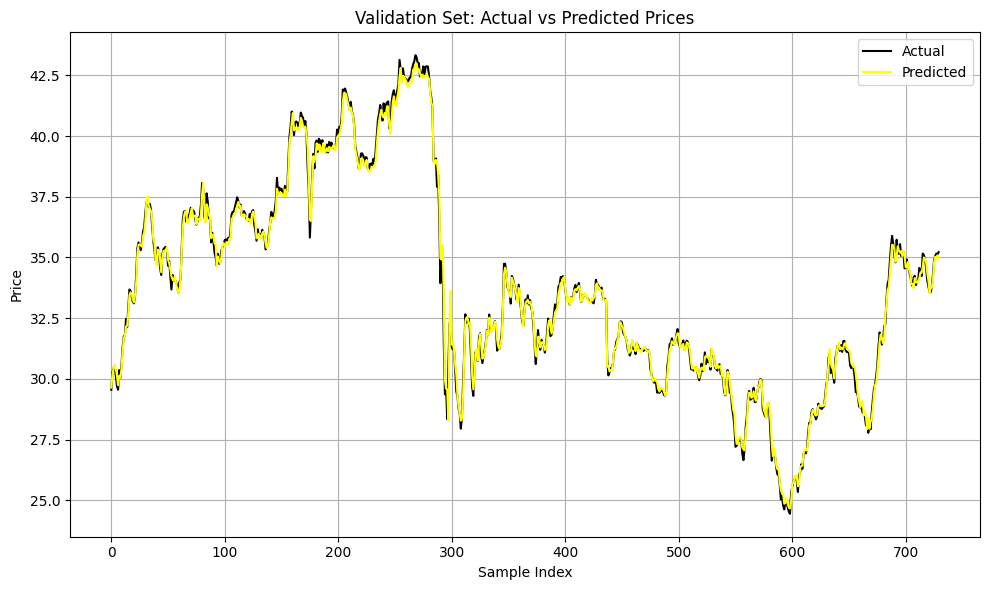

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# --- Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# --- Volume conversion
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    return vol_str

for df in [train, val, test]:
    df["Vol."] = df["Vol."].apply(convert_volume)

# --- Feature engineering
def engineer_features(df):
    df = df.copy()
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])
    df["price_range_pct"] = (df["High"] - df["Low"]) / df["Low"]
    df["Date"] = pd.to_datetime(df["Date"])
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df

train_fe = engineer_features(train)
val_fe = engineer_features(val)
test_fe = engineer_features(test)

features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "price_range_pct",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]
X_val = val_fe[features]
y_val = val_fe["Price"]
X_test = test_fe[features]

# --- Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Build the neural network with L2 regularization
l2_reg = 0.01
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(l2_reg)),
    Dropout(0.2),
    Dense(32, activation='relu', kernel_regularizer=l2(l2_reg)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# --- Early stopping
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

# --- Train model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=160,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# --- Evaluate model
val_preds = model.predict(X_val_scaled).flatten()
mae = mean_absolute_error(y_val, val_preds)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print(f"\nNNK - MAE: {mae:.4f}, RMSE: {rmse:.4f}")

# --- Plot: Predicted vs Actual on validation set
plt.figure(figsize=(10, 6))
plt.plot(y_val.values, color='black', label='Actual')
plt.plot(val_preds, color='yellow', label='Predicted')
plt.title("Validation Set: Actual vs Predicted Prices")
plt.xlabel("Sample Index")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Predict on test set
test_preds = model.predict(X_test_scaled).flatten()

# --- Save predictions
submission = pd.DataFrame({
    "ID": test["ID"],
    "Predicted_Close": test_preds
})
submission.to_csv("NkNK1.csv", index=False)


Epoch 1/160


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 164.5129 - mae: 9.1901 - val_loss: 64.9117 - val_mae: 7.5945
Epoch 2/160
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 12.1355 - mae: 2.7487 - val_loss: 8.0389 - val_mae: 1.8831
Epoch 3/160
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5.6379 - mae: 1.7988 - val_loss: 4.4290 - val_mae: 1.3637
Epoch 4/160
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3.9982 - mae: 1.5210 - val_loss: 2.4953 - val_mae: 0.9537
Epoch 5/160
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.4422 - mae: 1.3432 - val_loss: 2.4513 - val_mae: 0.9129
Epoch 6/160
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.0149 - mae: 1.2485 - val_loss: 1.4510 - val_mae: 0.6890
Epoch 7/160
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.4931 - mae: 1.1320 - val_loss: 1.4790 - val_mae: 0.7247
Epoch 8/160
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.4505 - mae: 1.1082 - val_loss: 1.5700 - val_mae: 0.7944
Epoch 9/160
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step -

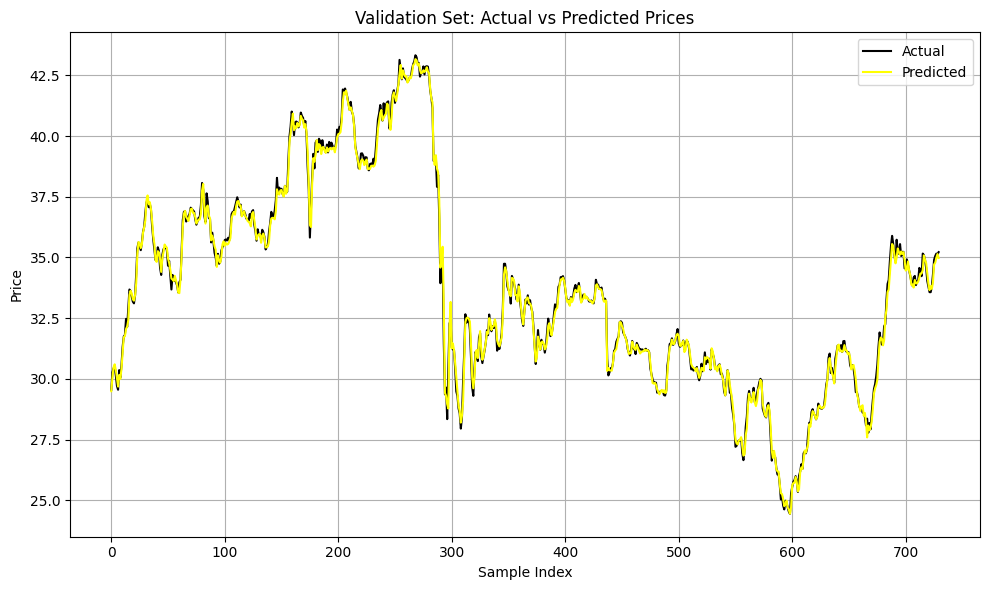

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
###########################################
# --- Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# --- Volume conversion
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    return vol_str

for df in [train, val, test]:
    df["Vol."] = df["Vol."].apply(convert_volume)

# --- Feature engineering
def engineer_features(df):
    df = df.copy()
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])
    df["price_range_pct"] = (df["High"] - df["Low"]) / df["Low"]
    df["Date"] = pd.to_datetime(df["Date"])
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df

train_fe = engineer_features(train)
val_fe = engineer_features(val)
test_fe = engineer_features(test)

features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "price_range_pct",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]
X_val = val_fe[features]
y_val = val_fe["Price"]
X_test = test_fe[features]

# --- Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Build the neural network with L2 regularization
l2_reg = 0.0001

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(l2_reg)),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# --- Early stopping
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

# --- Train model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=160,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# --- Evaluate model
val_preds = model.predict(X_val_scaled).flatten()
mae = mean_absolute_error(y_val, val_preds)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print(f"\nNNK - MAE: {mae:.4f}, RMSE: {rmse:.4f}")

# --- Plot: Predicted vs Actual on validation set
plt.figure(figsize=(10, 6))
plt.plot(y_val.values, color='black', label='Actual')
plt.plot(val_preds, color='yellow', label='Predicted')
plt.title("Validation Set: Actual vs Predicted Prices")
plt.xlabel("Sample Index")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Predict on test set
test_preds = model.predict(X_test_scaled).flatten()

# --- Save predictions
submission = pd.DataFrame({
    "ID": test["ID"],
    "Predicted_Close": test_preds
})
submission.to_csv("NkNK1.csv", index=False)
##################################################

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# --- Load datasets
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# --- Volume conversion
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    return vol_str

for df in [train, val, test]:
    df["Vol."] = df["Vol."].apply(convert_volume)

# --- Feature engineering
def engineer_features(df):
    df = df.copy()
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."])
    df["price_range_pct"] = (df["High"] - df["Low"]) / df["Low"]
    df["Date"] = pd.to_datetime(df["Date"])
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df

train_fe = engineer_features(train)
val_fe = engineer_features(val)
test_fe = engineer_features(test)

features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "price_range_pct",
    "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]
X_val = val_fe[features]
y_val = val_fe["Price"]
X_test = test_fe[features]

# --- Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Assume train, val datasets and features are loaded and preprocessed as before


# --- Grid search parameters for single layer NN
param_grid = {
    "neurons_1": [32, 64, 128],
    "l2_reg": [0.0001, 0.001, 0.01, 0.05, 0.005],
    "dropout": [0.2, 0.3],
    "activation": ["relu", "tanh"],
    "batch_size": [16, 32]
}

results = []
print("Starting grid search for 1-layer NN...")

for params in ParameterGrid(param_grid):
    model = Sequential()

    # Single hidden layer with L2, activation, dropout
    model.add(Dense(params["neurons_1"], activation=params["activation"],
                    kernel_regularizer=l2(params["l2_reg"]),
                    input_shape=(X_train_scaled.shape[1],)))
    model.add(Dropout(params["dropout"]))

    # Output layer (regression)
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(patience=10, restore_best_weights=True, verbose=0)

    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=150,
        batch_size=params["batch_size"],
        callbacks=[early_stop],
        verbose=0
    )

    val_preds = model.predict(X_val_scaled, verbose=0)
    mae = mean_absolute_error(y_val, val_preds)
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))

    results.append({
        "params": params,
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"Params: {params} => MAE: {mae:.4f}, RMSE: {rmse:.4f}")

# Convert to DataFrame and sort by RMSE
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE").reset_index(drop=True)

print("\nTop 5 configurations:")
print(results_df.head())

# Save top 5 results to CSV
results_df.head(5).to_csv("nn_grid_search_1layer_top5.csv", index=False)
print("\n✅ Top 5 results saved to 'nn_grid_search_1layer_top5.csv'")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.backend import clear_session
import itertools

# --- Load datasets (unchanged)
train = pd.read_csv("/content/train.csv")
val = pd.read_csv("/content/val.csv")
test = pd.read_csv("/content/test_without_label.csv")

# --- Volume conversion
def convert_volume(vol_str):
    if isinstance(vol_str, str):
        if "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        else:
            return float(vol_str)
    return vol_str

for df in [train, val, test]:
    df["Vol."] = df["Vol."].apply(convert_volume)

# --- Feature engineering
def engineer_features(df):
    df = df.copy()
    df["high_low_diff"] = df["High"] - df["Low"]
    df["log_volume"] = np.log1p(df["Vol."].clip(lower=0))
    df["price_range_pct"] = (df["High"] - df["Low"]) / df["Low"]
    df["Date"] = pd.to_datetime(df["Date"])
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df

train_fe = engineer_features(train)
val_fe = engineer_features(val)
test_fe = engineer_features(test)

features = [
    "Open", "High", "Low", "Vol.",
    "high_low_diff", "log_volume",
    "price_range_pct", "day_of_week", "month", "is_weekend"
]

X_train = train_fe[features]
y_train = train_fe["Price"]
X_val = val_fe[features]
y_val = val_fe["Price"]
X_test = test_fe[features]

# --- Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Grid search parameters (added neurons, batch_sizes, activations)
learning_rates = [0.001, 0.005, 0.01]
momentums = [0.8, 0.9]
l2_regs = [0.0001, 0.001, 0.005]
dropouts = [0.2, 0.3]
neurons = [32, 64, 128]          # added hidden layer size
batch_sizes = [32, 64]           # added batch size
activations = ['relu', 'tanh']   # added activation function

results = []

# --- Grid search loop with all parameters
for lr, mom, l2_reg, drop, n, batch, act in itertools.product(
    learning_rates, momentums, l2_regs, dropouts, neurons, batch_sizes, activations):

    clear_session()  # Clear previous model from memory

    print(f"\nTraining with lr={lr}, momentum={mom}, l2={l2_reg}, dropout={drop}, neurons={n}, batch_size={batch}, activation={act}")

    model = Sequential([
        Dense(n, activation=act, input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(l2_reg)),
        Dropout(drop),
        Dense(1)
    ])

    optimizer = SGD(learning_rate=lr, momentum=mom, nesterov=True, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(patience=10, restore_best_weights=True, verbose=0)

    model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=160,
        batch_size=batch,
        callbacks=[early_stop],
        verbose=0
    )

    val_preds = model.predict(X_val_scaled).flatten()
    mae = mean_absolute_error(y_val, val_preds)
    rmse = np.sqrt(mean_squared_error(y_val, val_preds))

    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")

    results.append({
        "learning_rate": lr,
        "momentum": mom,
        "l2_reg": l2_reg,
        "dropout": drop,
        "neurons": n,
        "batch_size": batch,
        "activation": act,
        "mae": mae,
        "rmse": rmse
    })

# --- Save results to CSV
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="mae")
results_df.to_csv("grid_searchSGD_results.csv", index=False)
print("\nSaved grid search results to grid_searchSGD_results.csv")
